## Importing necessary packages

* Packages for Text preprocessing

In [88]:
# Packages for Data Export
import pandas as pd
# Packages for EDA
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

* Packages for Text cleaning

In [89]:
import re #importing regular expression

* Importing packages for Tokenization

In [90]:
!pip install nltk


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [91]:
import nltk # Importing needed packages for tokenization
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to C:\Users\Sneha
[nltk_data]     R\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Sneha
[nltk_data]     R\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [92]:
from nltk.tokenize import word_tokenize # importing packages for word tekenization

* Importing packages for Normalization

In [93]:
!pip install contractions


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [94]:
import contractions # Finding the root words

* Importing packages for Lemetization & Stop words

In [95]:
nltk.download('wordnet') # Download the WordNet corpus for lemmatization
nltk.download('omw-1.4') # Download the Open Multilingual WordNet corpus for lemmatization
nltk.download('stopwords') # Download the stopwords corpus

[nltk_data] Downloading package wordnet to C:\Users\Sneha
[nltk_data]     R\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Sneha
[nltk_data]     R\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Sneha
[nltk_data]     R\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [96]:
from nltk.stem import WordNetLemmatizer # Import the WordNetLemmatizer for lemmatization
from nltk.corpus import stopwords # Import the stopwords corpus

* Importing packages for Vectorization

In [97]:
from sklearn.feature_extraction.text import TfidfVectorizer # Doing TF-IDF

# Exporting data

In [98]:
review_df=pd.read_csv("D:\sentiment analysis project\AI Echo.csv")

In [99]:
review_df.head(10)

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,########,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No
1,########,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No
2,########,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No
3,########,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes
4,########,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No
5,5/5/2024,Review title 6,"Waste of time, does not meet expectations.",2,user6,156,7,App Store,en,Nepal,3.5.6,No
6,3/9/2024,Review title 7,"Highly satisfied, the app works exactly as exp...",4,user7,186,8,Google Play,fr,Qatar,2.1.4,No
7,3/8/2024,Review title 8,"Highly satisfied, the app works exactly as exp...",4,user8,152,8,Amazon,ja,Italy,5.0.3,No
8,########,Review title 9,"Excellent app, very easy to use and extremely ...",4,user9,87,9,Amazon,en,Germany,5.0.3,No
9,########,Review title 10,"Great experience, smooth performance and usefu...",5,user10,27,7,Flipkart,en,Nepal,3.5.6,Yes


In [100]:
review_df.to_csv('raw_data.csv', index=False)

# Text preprocessing

In [101]:
review_df.head(10)

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,########,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No
1,########,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No
2,########,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No
3,########,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes
4,########,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No
5,5/5/2024,Review title 6,"Waste of time, does not meet expectations.",2,user6,156,7,App Store,en,Nepal,3.5.6,No
6,3/9/2024,Review title 7,"Highly satisfied, the app works exactly as exp...",4,user7,186,8,Google Play,fr,Qatar,2.1.4,No
7,3/8/2024,Review title 8,"Highly satisfied, the app works exactly as exp...",4,user8,152,8,Amazon,ja,Italy,5.0.3,No
8,########,Review title 9,"Excellent app, very easy to use and extremely ...",4,user9,87,9,Amazon,en,Germany,5.0.3,No
9,########,Review title 10,"Great experience, smooth performance and usefu...",5,user10,27,7,Flipkart,en,Nepal,3.5.6,Yes


In [102]:
review_df.columns

Index(['date', 'title', 'review', 'rating', 'username', 'helpful_votes',
       'review_length', 'platform', 'language', 'location', 'version',
       'verified_purchase'],
      dtype='object')

### Handling null values

In [103]:
review_df.isnull().sum()

date                 0
title                0
review               0
rating               0
username             0
helpful_votes        0
review_length        0
platform             0
language             0
location             0
version              0
verified_purchase    0
dtype: int64

### Deleting duplicate values

In [104]:
review_df.duplicated().sum()

np.int64(0)

### Deleting not required columns

In [105]:
review_df.drop(columns=['date'],inplace=True)

## Mapping sentiment for review_df

In [106]:
from textblob import TextBlob

In [107]:
def sentiment_mapping(text):
  blob=TextBlob(text)
  sentiment=blob.sentiment.polarity
  if sentiment>0.2:
    return 'Positive'
  elif sentiment<0.2:
    return 'Negative'
  else:
    return 'Neutral'

In [108]:
review_df['Sentiment'] = review_df['review'].apply(sentiment_mapping)

In [109]:
review_df.head(1)

,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase,Sentiment
0,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No,Negative


# EDA

## Importing pacakges for EDA

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

**Things to check**

1. 📊 What is the distribution of review ratings?
2. 👍👎 How many reviews were marked as helpful (above a certain threshold)?
3. 🧭 What are the most common keywords in positive vs. negative reviews?
4. 📆 How has the average rating changed over time?
5. 🌍 How do ratings vary by user location?
6. 🧑‍💻 Which platform (Web vs Mobile) gets better reviews?
7. ✅❌ 7. Are verified users more satisfied than non-verified ones?
8. 🔠 8. What’s the average length of reviews per rating category?
9. 💬 9. What are the most mentioned words in 1-star reviews?
10. 📱🧪 10. What ChatGPT version received the highest average rating?



In [111]:
#1 What is the distribution of review ratings?
# Bar plot

fig1 = px.histogram(review_df, x='rating', title='Distribution of Review Ratings', color='rating')

fig1.update_layout(
    width = 700,
    height = 500,
    xaxis_title='Rating',
    yaxis_title='Count',
    bargap=0.2,
    bargroupgap=0.1
)
fig1.update_layout(
    title_font=dict(color='#FF6F61', size=22),  # Title color
    xaxis_title=dict(font = dict(color='#999999', size=17)),
    yaxis_title=dict(font = dict(color='#999999', size=17)),
    template="plotly_dark")
fig1.show()

In [112]:
# 2.How many reviews were marked as helpful (above a certain threshold)?
# Pie chart

threshold = 10

review_df['is_helpful'] = review_df['helpful_votes'].apply(lambda x: '👍 Helpful' if x > threshold else '👎 Not Helpful')

fig2 = px.pie(review_df, names='is_helpful', title='👍 Helpful vs 👎 Not Helpful Reviews',)

fig2.update_traces(
    textposition='inside',
    textinfo='percent+label',
    hole=.2)

fig2.update_layout(
    width = 700,
    height = 500,
    xaxis_title=dict(font = dict(size=17)),
    yaxis_title=dict(font = dict(size=17)),
    title_font=dict(color='#E0E0E0', size=22), # Title color
    template="plotly_dark")
fig2.show()

In [113]:
# 3. What are the most common keywords in positive vs. negative reviews?

# word cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

review_df_positive = review_df[review_df['rating'] >= 4]
review_df_negative = review_df[review_df['rating'] <= 2]

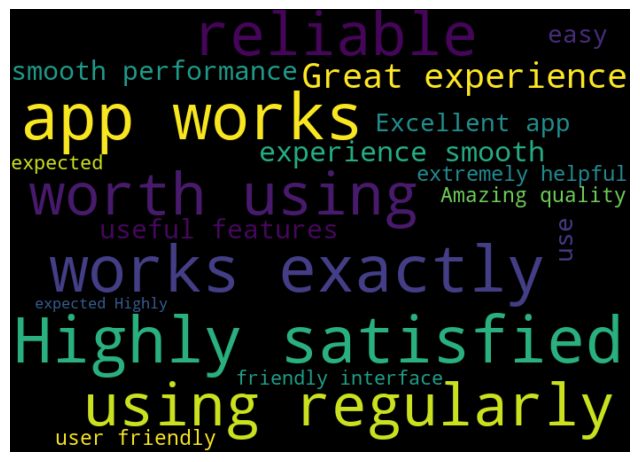

In [114]:
# Positive reviews
all_words = ' '.join([text for text in review_df_positive['review']])
wordcolud = WordCloud(width=700, height=500, random_state=21, max_font_size=110).generate(all_words)

plt.figure(figsize=(8, 6))
plt.imshow(wordcolud, interpolation="bilinear")
plt.axis('off')
plt.show()

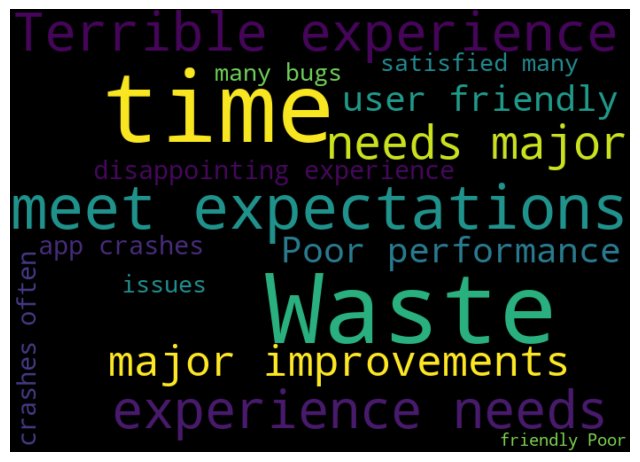

In [115]:
# Negative reviews
all_words = ' '.join([text for text in review_df_negative['review']])
wordcolud = WordCloud(width=700, height=500, random_state=21, max_font_size=110).generate(all_words)

plt.figure(figsize=(8, 6))
plt.imshow(wordcolud, interpolation="bilinear")
plt.axis('off')
plt.show()

In [116]:
# 5. How do ratings vary by user location?

country_df = review_df.groupby('location')['rating'].mean().reset_index()

fig = px.choropleth(
    country_df,
    locations='location',          # column with country names
    locationmode='country names',  # use country names instead of ISO codes
    color='rating',                # numeric column to color by
    hover_name='location',         # label on hover
    color_continuous_scale='Tealrose',  # nice gradient
    title='Average Rating by Country'
)

fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth',
        bgcolor='#0E1117'
    ),
    title_font=dict(size=26, color='#E0E0E0', family='Arial Black'),
    paper_bgcolor='#0E1117',
    plot_bgcolor='#0E1117',
    font=dict(color='white', size=14),
    margin=dict(t=90, b=30, l=20, r=20)
)

fig.update_coloraxes(
    colorbar_title='Average Rating',
    colorbar_title_font=dict(size=16, color='white'),
    colorbar_tickfont=dict(size=12, color='white')
)

fig.show()


In [117]:
# 6. Which platform gets better reviews?

platform_df = review_df.groupby('rating')['platform'].value_counts().reset_index(name='count')
platform_df

fig = px.bar(
    platform_df,
    x='platform',
    y='count',
    color='rating',
    title='Average Rating by Platform',
    barmode='stack'
)

fig.update_layout(
    width = 700,
    height = 500,
    xaxis_title='Platform',
    yaxis_title='Average Rating',
    title_font=dict(size=26, color='#E0E0E0', family='Arial Black'),
    template="plotly_dark")
fig.show()

In [118]:
# 7. Are verified users more satisfied than non-verified ones?

verified_df = review_df.groupby('rating')['verified_purchase'].value_counts().reset_index(name='count')

fig = px.bar(
    verified_df,
    x='verified_purchase',
    y='count',
    color='rating',
    title='Average Rating by Verified Purchase',
    barmode='stack'
)

fig.update_layout(
    width = 700,
    height = 500,
    xaxis_title='Verified Purchase',
    yaxis_title='Average Rating',
    title_font=dict(size=26, color='#E0E0E0', family='Arial Black'),
    template="plotly_dark")
fig.show()

In [119]:
verified_df

,rating,verified_purchase,count
0,1,Yes,45
1,1,No,44
2,2,No,62
3,2,Yes,44
4,3,Yes,54
5,3,No,51
6,4,No,55
7,4,Yes,55
8,5,No,50
9,5,Yes,40


In [120]:
# 8. What’s the average length of reviews per rating category?

review_df['review_length'] = review_df['review'].apply(lambda x: len(x.split()))
avg_review_length = review_df.groupby('rating')['review_length'].mean()
# avg_review_length

fig = px.bar(
    avg_review_length,
    x=avg_review_length.index,
    y=avg_review_length.values,
    color=avg_review_length.values,
    title='Average Review Length by Rating'
)

fig.update_layout(
    width = 700,
    height = 500,
    xaxis_title='Rating',
    yaxis_title='Average Review Length',
    title_font=dict(size=26, color='#E0E0E0', family='Arial Black'),
    template="plotly_dark")
fig.show()


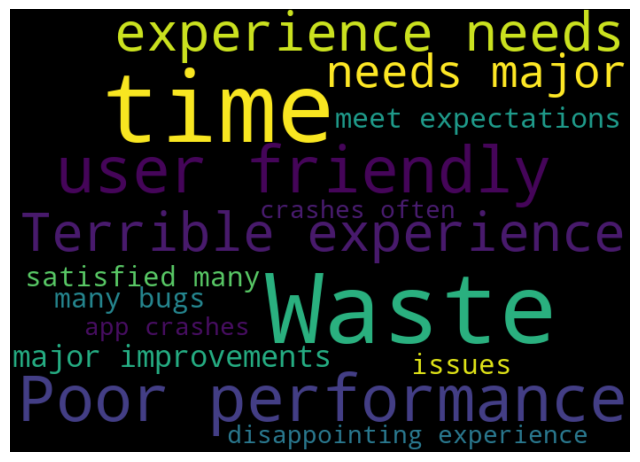

In [121]:
# 9. What are the most mentioned words in 1-star reviews?

review_df_1star = review_df[review_df['rating'] < 2]


# N1 Star reviews
all_words = ' '.join([text for text in review_df_1star['review']])
wordcolud = WordCloud(width=700, height=500, random_state=21, max_font_size=110).generate(all_words)

plt.figure(figsize=(8, 6))
plt.imshow(wordcolud, interpolation="bilinear")
plt.axis('off')
plt.show()

In [122]:
# 10. What ChatGPT version received the highest average rating?

version_avg_rating = review_df.groupby('version')['rating'].mean().reset_index()

fig = px.bar(
    version_avg_rating,
    x='version',
    y='rating',
    color='rating',
    title='Average Rating by ChatGPT Version',
    barmode='stack'
)

fig.update_layout(
    width = 3000,
    height = 500,
    xaxis_title='ChatGPT Version',
    yaxis_title='Average Rating',
    title_font=dict(size=26, color='#E0E0E0', family='Arial Black'),
    template="plotly_dark")
fig.show()

## EDA - Charts to display in streamlit

In [123]:
# 1.What is the overall sentiment of user reviews?

overall_sentiment = review_df['Sentiment'].value_counts()
overall_sentiment

fig = px.bar(
    overall_sentiment,
    x=overall_sentiment.index,
    y=overall_sentiment.values,
    color=overall_sentiment.values,
    title='Overall Sentiment of User Reviews'
)

fig.update_layout(
    width = 700,
    height = 500,
    xaxis_title='Sentiment',
    yaxis_title='Count',
    title_font=dict(size=26, color='#E0E0E0', family='Arial Black'),
    template="plotly_dark")
fig.show()

In [124]:
# 2.How does sentiment vary by rating?

rating_sentiment = review_df.groupby('rating')['Sentiment'].value_counts().reset_index(name='count')


fig = px.bar(
    rating_sentiment,
    x='rating',
    y='count',
    color='Sentiment',
    title='Sentiment by Rating',
    labels={'Sentiment': 'Sentiment', 'count': 'Number of Reviews', 'rating': 'Rating'}
)

fig.update_layout(
    width = 700,
    height = 500,
    xaxis_title='Rating',
    yaxis_title='Count',
    title_font=dict(size=26, color='#E0E0E0', family='Arial Black'),
    template="plotly_dark")
fig.show()

In [125]:
rating_sentiment

,rating,Sentiment,count
0,1,Negative,89
1,2,Negative,106
2,3,Positive,69
3,3,Negative,36
4,4,Positive,56
5,4,Neutral,34
6,4,Negative,20
7,5,Positive,51
8,5,Negative,23
9,5,Neutral,16


In [126]:
# 3.Which keywords or phrases are most associated with each sentiment class?
#  → Use word clouds or keyword frequency tables per sentiment type.

sentiment_positive = review_df[review_df['Sentiment'] == 'Positive']
sentiment_negative = review_df[review_df['Sentiment'] == 'Negative']
sentiment_neutral = review_df[review_df['Sentiment'] == 'Neutral']

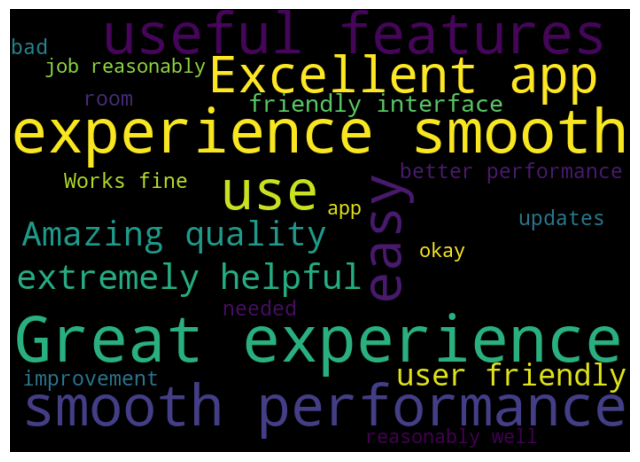

In [127]:
# Word colud for Positive

all_words = ' '.join([text for text in sentiment_positive['review']])
wordcolud = WordCloud(width=700, height=500, random_state=21, max_font_size=110).generate(all_words)

plt.figure(figsize=(8, 6))
plt.imshow(wordcolud, interpolation="bilinear")
plt.axis('off')
plt.show()

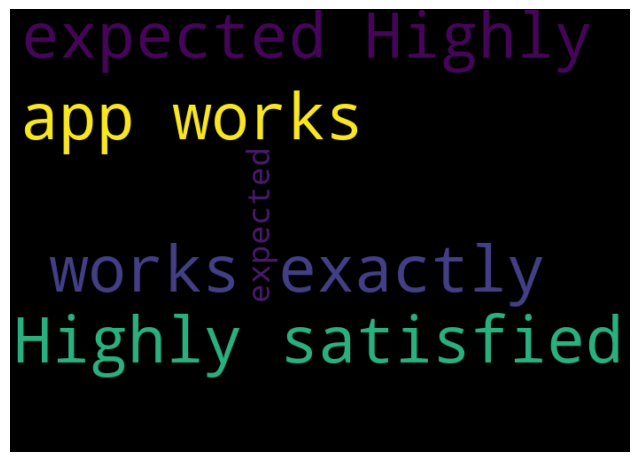

In [128]:
# Word colud for Neutral

all_words = ' '.join([text for text in sentiment_neutral['review']])
wordcolud = WordCloud(width=700, height=500, random_state=21, max_font_size=110).generate(all_words)

plt.figure(figsize=(8, 6))
plt.imshow(wordcolud, interpolation="bilinear")
plt.axis('off')
plt.show()

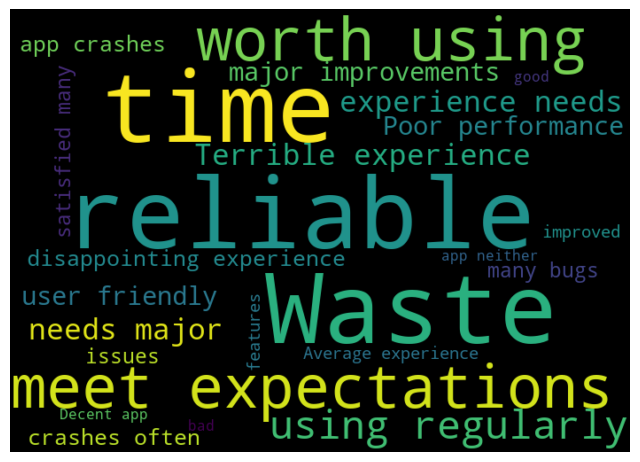

In [129]:
# Word colud for Negative

all_words = ' '.join([text for text in sentiment_negative['review']])
wordcolud = WordCloud(width=700, height=500, random_state=21, max_font_size=110).generate(all_words)

plt.figure(figsize=(8, 6))
plt.imshow(wordcolud, interpolation="bilinear")
plt.axis('off')
plt.show()

In [130]:
# 5.Do verified users tend to leave more positive or negative reviews?
#  → Compare sentiment distribution between verified_purchase = Yes vs. No.

verified_purchase_sentiment = review_df.groupby('verified_purchase')['Sentiment'].value_counts().reset_index(name='count')
verified_purchase_sentiment

fig = px.bar(
    verified_purchase_sentiment,
    x='verified_purchase',
    y='count',
    color='Sentiment',
    title='Sentiment Distribution by Verified Purchase',
    barmode='stack'
)

fig.update_layout(
    width = 700,
    height = 500,
    xaxis_title='Verified Purchase',
    yaxis_title='Count',
    title_font=dict(size=26, color='#E0E0E0', family='Arial Black'),
    template="plotly_dark")
fig.show()

In [131]:
# 6.Are longer reviews more likely to be negative or positive?
#  → Compare average sentiment scores with review length.

review_length_sentiment = review_df.groupby('Sentiment')['review_length'].mean().reset_index()
review_length_sentiment['review_length'] = review_length_sentiment['review_length'].round(0).astype(int)

fig = px.bar(
    review_length_sentiment,
    x='Sentiment',
    y='review_length',
    color='review_length',
    title='Average Review Length by Sentiment'
)

fig.update_layout(
    width = 700,
    height = 500,
    xaxis_title='Sentiment',
    yaxis_title='Average Review Length',
    title_font=dict(size=26, color='#E0E0E0', family='Arial Black'),
    template="plotly_dark")
fig.show()

In [132]:
# 7.Which locations show the most positive or negative sentiment?
#  → Helps uncover region-based user experience issues or appreciation.

location_sentiment = review_df.groupby('location')['Sentiment'].value_counts().reset_index(name='count')

fig = px.bar(
    location_sentiment,
    x='location',
    y='count',
    color='Sentiment',
    title='Sentiment Distribution by Location',
    barmode='stack'
)

fig.update_layout(
    width = 5000,
    height = 500,
    xaxis_title='Location',
    yaxis_title='Count',
    title_font=dict(size=26, color='#E0E0E0', family='Arial Black'),
    template="plotly_dark")
fig.show()

In [133]:
# 8.Is there a difference in sentiment across platforms (Web vs Mobile)?
#  → Identify where the user experience might need improvement.

platform_sentiment = review_df.groupby('platform')['Sentiment'].value_counts().reset_index(name='count')

fig = px.bar(
    platform_sentiment,
    x='platform',
    y='count',
    color='Sentiment',
    title='Sentiment Distribution by Platform',
    barmode='stack'
)

fig.update_layout(
    width = 700,
    height = 500,
    xaxis_title='Platform',
    yaxis_title='Count',
    title_font=dict(size=26, color='#E0E0E0', family='Arial Black'),
    template="plotly_dark")
fig.show()

In [134]:
# 9.Which ChatGPT versions are associated with higher/lower sentiment?
#  → Determine if a version release impacted user satisfaction.

version_sentiment = review_df.groupby('version')['Sentiment'].value_counts().reset_index(name='count')

fig = px.bar(
    version_sentiment,
    x='version',
    y='count',
    color='Sentiment',
    title='Sentiment Distribution by ChatGPT Version',
    barmode='stack'
)

fig.update_layout(
    width = 3000,
    height = 500,
    xaxis_title='ChatGPT Version',
    yaxis_title='Count',
    title_font=dict(size=26, color='#E0E0E0', family='Arial Black'),
    template="plotly_dark")
fig.show()

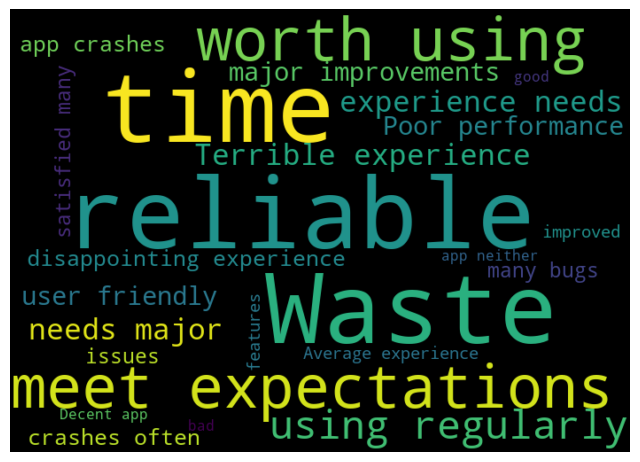

In [135]:
# 10.What are the most common negative feedback themes?
#  → Use topic modeling or keyword grouping to identify recurring pain points in negative reviews.

sentiment_negative = review_df[review_df['Sentiment'] == 'Negative']

all_words = ' '.join([text for text in sentiment_negative['review']])
wordcolud = WordCloud(width=700, height=500, random_state=21, max_font_size=110).generate(all_words)

plt.figure(figsize=(8, 6))
plt.imshow(wordcolud, interpolation="bilinear")
plt.axis('off')
plt.show()

# Text cleaning - (Functions)

## Function for Text preprocessing

In [136]:
#Function for lower case
def lowercase(text):
  return text.lower()

#remove url
def remove_urls(text):
  urls_pattern=re.compile(r'https?://\S+|www\.\S+')
  return urls_pattern.sub(r'',text)

# remove Mail
def remove_mail(text):
  mail_pattern=re.compile(r'\S+@\S+')
  return mail_pattern.sub(r'',text)

# remove HTML tags
def remove_html(text):
  html_pattern=re.compile('<.*?>')
  return html_pattern.sub(r'',text)

# remove punctuations
def remove_punctuations(text):
  punc_pattern=re.compile(r'[^\w\s]')
  return punc_pattern.sub(r'',text)

# remove numbers and number with text
def remove_numbers(text):
  text=re.sub(r'[A-Za-z]+\d+','',text)
  text=re.sub(r'\d+\s*[A-Za-z]+','',text)
  text=re.sub(r'\d+','',text)
  return text

# remove whitespace
def remove_whitespace(text):
    return re.sub(r'\s+', ' ', text).strip()

In [137]:
# combining all function as a single funcation
def text_cleaning(text):
  text=lowercase(text)
  text=remove_urls(text)
  text=remove_mail(text)
  text=remove_html(text)
  text=remove_punctuations(text)
  text=remove_numbers(text)
  text=remove_whitespace(text)
  return text

## Tokenization

In [138]:
def tokenize(text):
  return word_tokenize(text)

## Normalization

In [139]:
def expand_contractions(text):
  return contractions.fix(text)

## Lemetization & Stop words

In [140]:
# Lematize and stops words

stop_words=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()

def lemmatizer_stopwords(text):
  return [lemmatizer.lemmatize(word) for word in text if word not in stop_words]

## Creating new Data Frame fro Model building alone

In [141]:
senti_df = review_df[['review']].reset_index(drop=True)
senti_df

,review
0,"Not satisfied, many bugs and issues."
1,Amazing quality and user-friendly interface.
2,"Terrible experience, needs major improvements."
3,Poor performance and not user-friendly.
4,"Not satisfied, many bugs and issues."
...,...
495,"Waste of time, does not meet expectations."
496,"Great experience, smooth performance and usefu..."
497,"Terrible experience, needs major improvements."
498,"Highly satisfied, the app works exactly as exp..."


# Applying the written function

## Text cleaning

In [142]:
senti_df.head()

,review
0,"Not satisfied, many bugs and issues."
1,Amazing quality and user-friendly interface.
2,"Terrible experience, needs major improvements."
3,Poor performance and not user-friendly.
4,"Not satisfied, many bugs and issues."


In [143]:
senti_df.columns

Index(['review'], dtype='object')

In [144]:
# def text_cleaning(text)
senti_df['cleaned_review'] = senti_df['review'].apply(text_cleaning)
senti_df

,review,cleaned_review
0,"Not satisfied, many bugs and issues.",not satisfied many bugs and issues
1,Amazing quality and user-friendly interface.,amazing quality and userfriendly interface
2,"Terrible experience, needs major improvements.",terrible experience needs major improvements
3,Poor performance and not user-friendly.,poor performance and not userfriendly
4,"Not satisfied, many bugs and issues.",not satisfied many bugs and issues
...,...,...
495,"Waste of time, does not meet expectations.",waste of time does not meet expectations
496,"Great experience, smooth performance and usefu...",great experience smooth performance and useful...
497,"Terrible experience, needs major improvements.",terrible experience needs major improvements
498,"Highly satisfied, the app works exactly as exp...",highly satisfied the app works exactly as expe...


## Normalization

In [145]:
senti_df['expanded_review'] = senti_df['cleaned_review'].apply(expand_contractions)
senti_df.head()

,review,cleaned_review,expanded_review
0,"Not satisfied, many bugs and issues.",not satisfied many bugs and issues,not satisfied many bugs and issues
1,Amazing quality and user-friendly interface.,amazing quality and userfriendly interface,amazing quality and userfriendly interface
2,"Terrible experience, needs major improvements.",terrible experience needs major improvements,terrible experience needs major improvements
3,Poor performance and not user-friendly.,poor performance and not userfriendly,poor performance and not userfriendly
4,"Not satisfied, many bugs and issues.",not satisfied many bugs and issues,not satisfied many bugs and issues


## Tokenize

In [146]:
senti_df['tokenized_review'] = senti_df['expanded_review'].apply(tokenize)
senti_df.head()

,review,cleaned_review,expanded_review,tokenized_review
0,"Not satisfied, many bugs and issues.",not satisfied many bugs and issues,not satisfied many bugs and issues,"[not, satisfied, many, bugs, and, issues]"
1,Amazing quality and user-friendly interface.,amazing quality and userfriendly interface,amazing quality and userfriendly interface,"[amazing, quality, and, userfriendly, interface]"
2,"Terrible experience, needs major improvements.",terrible experience needs major improvements,terrible experience needs major improvements,"[terrible, experience, needs, major, improveme..."
3,Poor performance and not user-friendly.,poor performance and not userfriendly,poor performance and not userfriendly,"[poor, performance, and, not, userfriendly]"
4,"Not satisfied, many bugs and issues.",not satisfied many bugs and issues,not satisfied many bugs and issues,"[not, satisfied, many, bugs, and, issues]"


## Lemmatizer and Stopwords

In [147]:
senti_df['lemmatizer_stopwords_text']=senti_df['tokenized_review'].apply(lemmatizer_stopwords)
senti_df.head()

,review,cleaned_review,expanded_review,tokenized_review,lemmatizer_stopwords_text
0,"Not satisfied, many bugs and issues.",not satisfied many bugs and issues,not satisfied many bugs and issues,"[not, satisfied, many, bugs, and, issues]","[satisfied, many, bug, issue]"
1,Amazing quality and user-friendly interface.,amazing quality and userfriendly interface,amazing quality and userfriendly interface,"[amazing, quality, and, userfriendly, interface]","[amazing, quality, userfriendly, interface]"
2,"Terrible experience, needs major improvements.",terrible experience needs major improvements,terrible experience needs major improvements,"[terrible, experience, needs, major, improveme...","[terrible, experience, need, major, improvement]"
3,Poor performance and not user-friendly.,poor performance and not userfriendly,poor performance and not userfriendly,"[poor, performance, and, not, userfriendly]","[poor, performance, userfriendly]"
4,"Not satisfied, many bugs and issues.",not satisfied many bugs and issues,not satisfied many bugs and issues,"[not, satisfied, many, bugs, and, issues]","[satisfied, many, bug, issue]"


## Final fully cleaned text

In [148]:
senti_df['Final_text'] = senti_df['lemmatizer_stopwords_text'].apply(lambda x: ' '.join(x))
senti_df.head()

,review,cleaned_review,expanded_review,tokenized_review,lemmatizer_stopwords_text,Final_text
0,"Not satisfied, many bugs and issues.",not satisfied many bugs and issues,not satisfied many bugs and issues,"[not, satisfied, many, bugs, and, issues]","[satisfied, many, bug, issue]",satisfied many bug issue
1,Amazing quality and user-friendly interface.,amazing quality and userfriendly interface,amazing quality and userfriendly interface,"[amazing, quality, and, userfriendly, interface]","[amazing, quality, userfriendly, interface]",amazing quality userfriendly interface
2,"Terrible experience, needs major improvements.",terrible experience needs major improvements,terrible experience needs major improvements,"[terrible, experience, needs, major, improveme...","[terrible, experience, need, major, improvement]",terrible experience need major improvement
3,Poor performance and not user-friendly.,poor performance and not userfriendly,poor performance and not userfriendly,"[poor, performance, and, not, userfriendly]","[poor, performance, userfriendly]",poor performance userfriendly
4,"Not satisfied, many bugs and issues.",not satisfied many bugs and issues,not satisfied many bugs and issues,"[not, satisfied, many, bugs, and, issues]","[satisfied, many, bug, issue]",satisfied many bug issue


In [149]:
senti_df.drop(columns=['cleaned_review','expanded_review','tokenized_review','lemmatizer_stopwords_text'],inplace=True)
senti_df.head()

,review,Final_text
0,"Not satisfied, many bugs and issues.",satisfied many bug issue
1,Amazing quality and user-friendly interface.,amazing quality userfriendly interface
2,"Terrible experience, needs major improvements.",terrible experience need major improvement
3,Poor performance and not user-friendly.,poor performance userfriendly
4,"Not satisfied, many bugs and issues.",satisfied many bug issue


In [150]:
senti_df.rename(columns={'Final_text': 'Final_cleaned_review'}, inplace=True)
senti_df.head()

,review,Final_cleaned_review
0,"Not satisfied, many bugs and issues.",satisfied many bug issue
1,Amazing quality and user-friendly interface.,amazing quality userfriendly interface
2,"Terrible experience, needs major improvements.",terrible experience need major improvement
3,Poor performance and not user-friendly.,poor performance userfriendly
4,"Not satisfied, many bugs and issues.",satisfied many bug issue


# Review mapping to Positive, Neutral or Negative

## Sentiment mapping with Textblob

In [151]:
from textblob import TextBlob

In [152]:
blob=TextBlob("This is a very good mobile phone")
sentiment=blob.sentiment.polarity

In [153]:
sentiment

0.9099999999999999

In [154]:
def sentiment_mapping(text):
  blob=TextBlob(text)
  sentiment=blob.sentiment.polarity
  if sentiment>0.2:
    return 'Positive'
  elif sentiment<0.2:
    return 'Negative'
  else:
    return 'Neutral'

In [155]:
senti_df['sentiment_score']=senti_df['Final_cleaned_review'].apply(sentiment_mapping)
senti_df.head()

,review,Final_cleaned_review,sentiment_score
0,"Not satisfied, many bugs and issues.",satisfied many bug issue,Positive
1,Amazing quality and user-friendly interface.,amazing quality userfriendly interface,Positive
2,"Terrible experience, needs major improvements.",terrible experience need major improvement,Negative
3,Poor performance and not user-friendly.,poor performance userfriendly,Negative
4,"Not satisfied, many bugs and issues.",satisfied many bug issue,Positive


In [156]:
senti_df['sentiment_score'].value_counts()

sentiment_score
Negative    266
Positive    184
Neutral      50
Name: count, dtype: int64

In [157]:
senti_df.isnull().sum()

review                  0
Final_cleaned_review    0
sentiment_score         0
dtype: int64

In [158]:
senti_df.duplicated().sum()

np.int64(485)

In [159]:
senti_df=senti_df.drop_duplicates()

In [160]:
senti_df.shape

(15, 3)

In [161]:
senti_df.head()

,review,Final_cleaned_review,sentiment_score
0,"Not satisfied, many bugs and issues.",satisfied many bug issue,Positive
1,Amazing quality and user-friendly interface.,amazing quality userfriendly interface,Positive
2,"Terrible experience, needs major improvements.",terrible experience need major improvement,Negative
3,Poor performance and not user-friendly.,poor performance userfriendly,Negative
5,"Waste of time, does not meet expectations.",waste time meet expectation,Negative


In [162]:
senti_df.duplicated().sum()

np.int64(0)

In [163]:
senti_df.to_csv('cleaned_df.csv', index=False)

## Vectorization(TF-IDF)

In [164]:
from sklearn.feature_extraction.text import TfidfVectorizer

**Steps to do before model buliding for text classification**
1. Text Cleaning
2. Tokenization
3. Expanding Contractions
4. Removing Stopwords
5. Lemmatization
6. Vectorization

# Model Building

In [165]:
senti_df

,review,Final_cleaned_review,sentiment_score
0,"Not satisfied, many bugs and issues.",satisfied many bug issue,Positive
1,Amazing quality and user-friendly interface.,amazing quality userfriendly interface,Positive
2,"Terrible experience, needs major improvements.",terrible experience need major improvement,Negative
3,Poor performance and not user-friendly.,poor performance userfriendly,Negative
5,"Waste of time, does not meet expectations.",waste time meet expectation,Negative
6,"Highly satisfied, the app works exactly as exp...",highly satisfied app work exactly expected,Neutral
8,"Excellent app, very easy to use and extremely ...",excellent app easy use extremely helpful,Positive
9,"Great experience, smooth performance and usefu...",great experience smooth performance useful fea...,Positive
10,Works fine but there is room for improvement.,work fine room improvement,Positive
11,"Not bad, but updates are needed for better per...",bad update needed better performance,Negative


In [166]:
x=senti_df['Final_cleaned_review']
y=senti_df['sentiment_score']

In [167]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((12,), (3,), (12,), (3,))

## Importing packages for Model building

In [168]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [169]:
#Pipeline
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

In [170]:
# tfidf = TfidfVectorizer()
# x_train_tfidf = tfidf.fit_transform(x_train)

# smote = SMOTE(random_state=42)
# x_train_resampled, y_train_resampled = smote.fit_resample(x_train_tfidf, y_train)

In [171]:
from sklearn.metrics import confusion_matrix


In [172]:
nb_pipeline=Pipeline([
    ('tfidf',TfidfVectorizer()),
    ('nb',MultinomialNB())
])

nb_pipeline.fit(x_train,y_train)

y_train_pred=nb_pipeline.predict(x_train)
y_test_pred=nb_pipeline.predict(x_test)

print(classification_report(y_train,y_train_pred))
print(classification_report(y_test,y_test_pred))



              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         6
     Neutral       0.00      0.00      0.00         1
    Positive       0.83      1.00      0.91         5

    accuracy                           0.92        12
   macro avg       0.61      0.67      0.64        12
weighted avg       0.85      0.92      0.88        12

              precision    recall  f1-score   support

    Negative       0.67      1.00      0.80         2
    Positive       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



In [173]:
#SVM

from sklearn.svm import SVC


In [174]:
svm_pipeline=Pipeline([
    ('tfidf',TfidfVectorizer()),
    ('svm',SVC())
])

svm_pipeline.fit(x_train,y_train)

y_train_pred=svm_pipeline.predict(x_train)
y_test_pred=svm_pipeline.predict(x_test)

print(classification_report(y_train,y_train_pred))
print(classification_report(y_test,y_test_pred))



              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         6
     Neutral       1.00      1.00      1.00         1
    Positive       1.00      1.00      1.00         5

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12

              precision    recall  f1-score   support

    Negative       0.67      1.00      0.80         2
    Positive       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



In [175]:
# Logistice regression
from sklearn.linear_model import LogisticRegression

In [176]:
lg_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('lg', LogisticRegression(class_weight='balanced'))
])

lg_pipeline.fit(x_train, y_train)

y_train_pred = lg_pipeline.predict(x_train)
y_test_pred = lg_pipeline.predict(x_test)

print(classification_report(y_train, y_train_pred))
print(classification_report(y_test, y_test_pred))


              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         6
     Neutral       1.00      1.00      1.00         1
    Positive       1.00      1.00      1.00         5

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         2
     Neutral       0.00      0.00      0.00         0
    Positive       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.33      0.33         3
weighted avg       0.67      0.67      0.67         3



> Model is overfit due to unwanted repetive words

In [177]:
# word cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

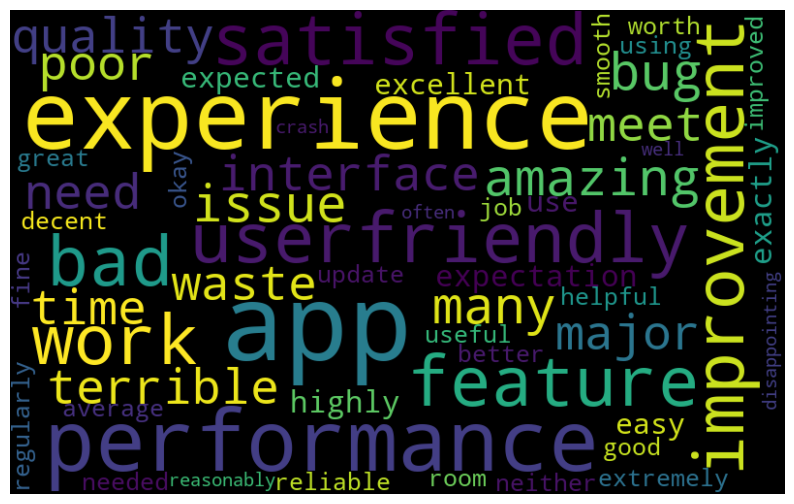

In [178]:
all_words = ' '.join([text for text in senti_df['Final_cleaned_review']])
wordcolud = WordCloud(width=800, height=500, random_state=21, max_font_size=110).generate(all_words)

plt.figure(figsize=(10, 7))
plt.imshow(wordcolud, interpolation="bilinear")
plt.axis('off')
plt.show()

In [179]:
freq=pd.Series(' '.join(senti_df['Final_cleaned_review']).split()).value_counts()
freq

app              5
experience       4
performance      3
satisfied        2
improvement      2
userfriendly     2
work             2
bad              2
feature          2
quality          1
interface        1
issue            1
many             1
need             1
amazing          1
terrible         1
waste            1
poor             1
time             1
meet             1
highly           1
expectation      1
major            1
bug              1
expected         1
exactly          1
excellent        1
easy             1
helpful          1
great            1
use              1
extremely        1
useful           1
smooth           1
fine             1
room             1
update           1
needed           1
better           1
decent           1
neither          1
good             1
reliable         1
worth            1
using            1
regularly        1
average          1
could            1
improved         1
okay             1
job              1
reasonably       1
well        

In [180]:
freq.describe()

count    56.000000
mean      1.267857
std       0.750541
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       5.000000
Name: count, dtype: float64

In [181]:
freq_5 = freq[freq<=10]
freq_5

app              5
experience       4
performance      3
satisfied        2
improvement      2
userfriendly     2
work             2
bad              2
feature          2
quality          1
interface        1
issue            1
many             1
need             1
amazing          1
terrible         1
waste            1
poor             1
time             1
meet             1
highly           1
expectation      1
major            1
bug              1
expected         1
exactly          1
excellent        1
easy             1
helpful          1
great            1
use              1
extremely        1
useful           1
smooth           1
fine             1
room             1
update           1
needed           1
better           1
decent           1
neither          1
good             1
reliable         1
worth            1
using            1
regularly        1
average          1
could            1
improved         1
okay             1
job              1
reasonably       1
well        

In [182]:
senti_df['Final_text_new']=senti_df['Final_cleaned_review'].apply(lambda x: ' '.join([word for word in x.split() if word not in freq_5]))
senti_df['Final_text_new']

0     
1     
2     
3     
5     
6     
8     
9     
10    
11    
19    
22    
24    
25    
31    
Name: Final_text_new, dtype: object

In [183]:
import pickle

pickle.dump(lg_pipeline, open("Model_log-new_data.pkl", "wb"))
